# BioRAG-X — 01 Dataset Forensics

**Purpose:** establish the canonical understanding of `rag-mini-bioasq` before implementing chunking, indexing, agentic retrieval, GraphRAG, PageIndex, or generation.

This notebook focuses on:
1. Dataset/schema discovery
2. Corpus/question integrity
3. Gold-answer and gold-passage analysis
4. Passage-to-question coverage
5. Multi-passage evidence complexity
6. Question-type profiling
7. Duplicate/leakage-risk checks
8. Statistics that drive later architecture decisions
9. Reproducible exports for downstream notebooks

> This is the forensic/development notebook. We do not tune retrieval models here and we do not lock the final 100-query benchmark here.

## Upstream dataset snapshot

The current Hugging Face dataset exposes two subsets:
- `question-answer-passages` — ~4.72k QA rows
- `text-corpus` — ~40.2k corpus rows

The QA subset currently exposes `question`, `answer`, `relevant_passage_ids`, and `id`. The dataset is derived from BioASQ and provides gold passage IDs that can be used for retrieval evaluation.

Sources:
- https://huggingface.co/datasets/rag-datasets/rag-mini-bioasq
- https://huggingface.co/datasets/rag-datasets/rag-mini-bioasq/viewer/question-answer-passages/test

In [1]:
# Core dependencies
from pathlib import Path
from ast import literal_eval
from collections import Counter
import hashlib
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, load_dataset_builder

SEED = 42
DATASET_ID = "rag-datasets/rag-mini-bioasq"
QA_CONFIG = "question-answer-passages"
CORPUS_CONFIG = "text-corpus"
ARTIFACT_DIR = Path("artifacts/01_dataset_forensics")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)

## 1. Discover the runtime dataset structure

In [2]:
def discover_config(config_name):
    builder = load_dataset_builder(DATASET_ID, config_name)
    info = builder.info
    print(f"CONFIG: {config_name}")
    print("Description:", (info.description or "")[:500])
    print("Features:")
    for name, feature in info.features.items():
        print(f"  - {name}: {feature}")
    print("Splits:")
    for split_name, split_info in info.splits.items():
        print(f"  - {split_name}: {split_info.num_examples:,} rows")
    return builder

qa_builder = discover_config(QA_CONFIG)
print()
corpus_builder = discover_config(CORPUS_CONFIG)

CONFIG: question-answer-passages
Description: 
Features:
  - question: Value('string')
  - answer: Value('string')
  - relevant_passage_ids: Value('string')
  - id: Value('int64')
Splits:
  - test: 4,719 rows

CONFIG: text-corpus
Description: 
Features:
  - passage: Value('string')
  - id: Value('int64')
Splits:
  - passages: 40,221 rows


### Why runtime discovery matters

BioRAG-X should depend on a canonical internal schema, not hard-coded upstream column names. The next cells normalize the source into a stable QA/corpus contract while retaining the original data.

## 2. Load QA and corpus data

In [3]:
def first_split(dataset_dict):
    names = list(dataset_dict.keys())
    if not names:
        raise ValueError("Dataset configuration has no splits")
    return names[0]

qa_raw_dict = load_dataset(DATASET_ID, QA_CONFIG)
corpus_raw_dict = load_dataset(DATASET_ID, CORPUS_CONFIG)
qa_split = "test" if "test" in qa_raw_dict else first_split(qa_raw_dict)
corpus_split = "passages" if "passages" in corpus_raw_dict else first_split(corpus_raw_dict)
qa = qa_raw_dict[qa_split].to_pandas()
corpus = corpus_raw_dict[corpus_split].to_pandas()

print(f"QA split     : {qa_split} -> {len(qa):,} rows")
print(f"Corpus split : {corpus_split} -> {len(corpus):,} rows")
print("QA columns:", list(qa.columns))
print("Corpus columns:", list(corpus.columns))

QA split     : test -> 4,719 rows
Corpus split : passages -> 40,221 rows
QA columns: ['question', 'answer', 'relevant_passage_ids', 'id']
Corpus columns: ['passage', 'id']


In [4]:
display(qa.head(3))
display(corpus.head(3))

,question,answer,relevant_passage_ids,id
0,Is Hirschsprung disease a mendelian or a multi...,"Coding sequence mutations in RET, GDNF, EDNRB,...","[20598273, 6650562, 15829955, 15617541, 230011...",0
1,List signaling molecules (ligands) that intera...,The 7 known EGFR ligands are: epidermal growt...,"[23821377, 24323361, 23382875, 22247333, 23787...",1
2,Is the protein Papilin secreted?,"Yes, papilin is a secreted protein","[21784067, 19297413, 15094122, 7515725, 332004...",2


,passage,id
0,New data on viruses isolated from patients wit...,9797
1,We describe an improved method for detecting d...,11906
2,We have studied the effects of curare on respo...,16083


## 3. Canonicalize schema

In [5]:
def normalize_passage_ids(value):
    """Parse passage IDs returned as lists, tuples, numpy arrays, or strings like '[1, 2]'."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, (list, tuple, set, np.ndarray)):
        raw = list(value)
    elif isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            parsed = literal_eval(value)
            raw = list(parsed) if isinstance(parsed, (list, tuple, set)) else [parsed]
        except (ValueError, SyntaxError):
            raw = re.findall(r"\d+", value)
    else:
        raw = [value]
    result = []
    seen = set()
    for x in raw:
        sx = str(x).strip()
        try:
            y = int(sx) if sx.isdigit() else sx
        except Exception:
            y = sx
        if str(y) not in seen:
            seen.add(str(y))
            result.append(y)
    return result


def normalize_qa(frame):
    required = {"question", "answer", "relevant_passage_ids", "id"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"QA schema missing required columns: {sorted(missing)}")
    out = frame.copy().rename(columns={"id": "question_id"})
    out["question_id"] = out["question_id"].astype(int)
    out["question"] = out["question"].fillna("").astype(str).str.strip()
    out["answer"] = out["answer"].fillna("").astype(str).str.strip()
    out["gold_passage_ids"] = out["relevant_passage_ids"].apply(normalize_passage_ids)
    return out


def infer_id_col(frame):
    for col in ["id", "passage_id", "pmid", "document_id"]:
        if col in frame.columns:
            return col
    raise ValueError(f"No passage ID column found. Columns: {list(frame.columns)}")


def infer_text_col(frame):
    for col in ["text", "passage", "document", "content"]:
        if col in frame.columns:
            return col
    string_cols = [c for c in frame.columns if frame[c].dtype == "object"]
    if not string_cols:
        raise ValueError("No string column found for corpus text")
    return max(string_cols, key=lambda c: frame[c].fillna("").astype(str).str.len().median())

qa_norm = normalize_qa(qa)
corpus_id_col = infer_id_col(corpus)
corpus_text_col = infer_text_col(corpus)
corpus_norm = corpus.copy().rename(columns={corpus_id_col:"passage_id", corpus_text_col:"passage_text"})
corpus_norm["passage_id"] = corpus_norm["passage_id"].apply(lambda x: int(str(x)) if str(x).isdigit() else str(x).strip())
corpus_norm["passage_text"] = corpus_norm["passage_text"].fillna("").astype(str).str.strip()

print("QA columns after normalization:", list(qa_norm.columns))
print("Corpus columns after normalization:", list(corpus_norm.columns))
print("Detected corpus ID column:", corpus_id_col)
print("Detected corpus text column:", corpus_text_col)

QA columns after normalization: ['question', 'answer', 'relevant_passage_ids', 'question_id', 'gold_passage_ids']
Corpus columns after normalization: ['passage_text', 'passage_id']
Detected corpus ID column: id
Detected corpus text column: passage


## 4. Schema integrity checks

In [6]:
def _safe_nunique(series):
    """nunique that tolerates unhashable values (e.g. list columns like gold_passage_ids)."""
    try:
        return int(series.nunique(dropna=False))
    except TypeError:
        return int(series.map(lambda v: str(v)).nunique(dropna=False))

def schema_report(frame, name):
    rows = []
    for col in frame.columns:
        rows.append({
            "dataset": name,
            "column": col,
            "dtype": str(frame[col].dtype),
            "rows": len(frame),
            "null_count": int(frame[col].isna().sum()),
            "null_pct": round(100 * frame[col].isna().mean(), 3),
            "n_unique": _safe_nunique(frame[col]),
        })
    return pd.DataFrame(rows)

schema_df = pd.concat([schema_report(qa_norm, "qa"), schema_report(corpus_norm, "corpus")], ignore_index=True)
display(schema_df)

assert qa_norm["question_id"].is_unique
assert corpus_norm["passage_id"].is_unique

print("Empty questions:", int((qa_norm.question == "").sum()))
print("Empty answers:", int((qa_norm.answer == "").sum()))
print("Empty corpus passages:", int((corpus_norm.passage_text == "").sum()))

,dataset,column,dtype,rows,null_count,null_pct,n_unique
0,qa,question,object,4719,0,0.0,4719
1,qa,answer,object,4719,0,0.0,4693
2,qa,relevant_passage_ids,object,4719,0,0.0,4596
3,qa,question_id,int32,4719,0,0.0,4719
4,qa,gold_passage_ids,object,4719,0,0.0,4596
5,corpus,passage_text,object,40221,0,0.0,27975
6,corpus,passage_id,int64,40221,0,0.0,40221


Empty questions: 0
Empty answers: 0
Empty corpus passages: 0


## 5. Length and evidence statistics

In [7]:
qa_norm["question_chars"] = qa_norm.question.str.len()
qa_norm["answer_chars"] = qa_norm.answer.str.len()
qa_norm["question_words"] = qa_norm.question.str.split().str.len()
qa_norm["answer_words"] = qa_norm.answer.str.split().str.len()
qa_norm["gold_passage_count"] = qa_norm.gold_passage_ids.str.len()

corpus_norm["passage_chars"] = corpus_norm.passage_text.str.len()
corpus_norm["passage_words"] = corpus_norm.passage_text.str.split().str.len()
corpus_norm["passage_hash"] = corpus_norm.passage_text.map(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest())

stats = pd.DataFrame({
    "metric":[
        "QA rows","Corpus rows","Question median words","Question p95 words",
        "Answer median words","Answer p95 words","Gold passages median","Gold passages p95",
        "Corpus passage median words","Corpus passage p95 words"],
    "value":[
        len(qa_norm),len(corpus_norm),qa_norm.question_words.median(),qa_norm.question_words.quantile(.95),
        qa_norm.answer_words.median(),qa_norm.answer_words.quantile(.95),qa_norm.gold_passage_count.median(),
        qa_norm.gold_passage_count.quantile(.95),corpus_norm.passage_words.median(),corpus_norm.passage_words.quantile(.95)]
})
display(stats)

,metric,value
0,QA rows,4719.0
1,Corpus rows,40221.0
2,Question median words,8.0
3,Question p95 words,15.0
4,Answer median words,24.0
5,Answer p95 words,105.0
6,Gold passages median,6.0
7,Gold passages p95,27.0
8,Corpus passage median words,163.0
9,Corpus passage p95 words,311.0


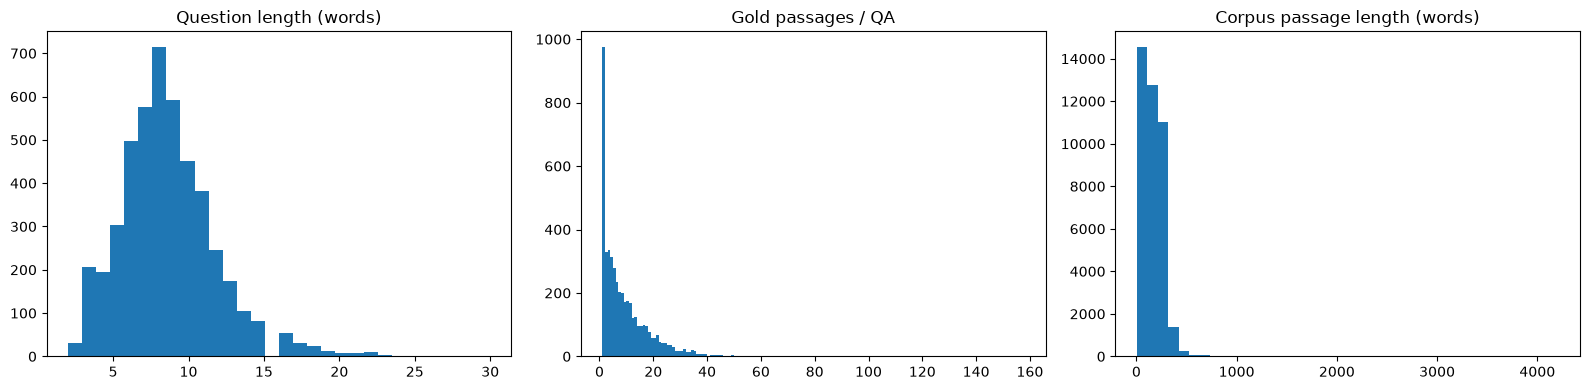

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(qa_norm.question_words, bins=30); axes[0].set_title("Question length (words)")
axes[1].hist(qa_norm.gold_passage_count, bins=range(1, int(qa_norm.gold_passage_count.max())+2)); axes[1].set_title("Gold passages / QA")
axes[2].hist(corpus_norm.passage_words, bins=40); axes[2].set_title("Corpus passage length (words)")
plt.tight_layout(); plt.show()

## 6. Gold-passage integrity

In [9]:
corpus_ids = set(corpus_norm.passage_id.tolist())
qa_norm["missing_gold_passage_ids"] = qa_norm.gold_passage_ids.apply(lambda ids: [pid for pid in ids if pid not in corpus_ids])
qa_norm["missing_gold_count"] = qa_norm.missing_gold_passage_ids.str.len()
qa_norm["gold_passage_count_present"] = qa_norm.gold_passage_count - qa_norm.missing_gold_count

integrity = pd.Series({
    "qa_rows": len(qa_norm),
    "qa_with_all_gold_passages_present": int((qa_norm.missing_gold_count == 0).sum()),
    "qa_with_missing_gold_passages": int((qa_norm.missing_gold_count > 0).sum()),
    "gold_passage_references": int(qa_norm.gold_passage_count.sum()),
    "missing_gold_references": int(qa_norm.missing_gold_count.sum()),
})
display(integrity.to_frame("value"))

if (qa_norm.missing_gold_count > 0).any():
    display(qa_norm.loc[qa_norm.missing_gold_count > 0, ["question_id","question","gold_passage_ids","missing_gold_passage_ids"]].head(20))

,value
qa_rows,4719
qa_with_all_gold_passages_present,4719
qa_with_missing_gold_passages,0
gold_passage_references,42608
missing_gold_references,0


## 7. Evidence complexity

In [10]:
qa_norm["evidence_complexity"] = np.select(
    [qa_norm.gold_passage_count <= 1,
     qa_norm.gold_passage_count == 2,
     qa_norm.gold_passage_count.between(3,5),
     qa_norm.gold_passage_count >= 6],
    ["single-passage","two-passage","multi-passage-3-to-5","multi-passage-6-plus"],
    default="unknown"
)
complexity = qa_norm.evidence_complexity.value_counts().rename_axis("evidence_complexity").reset_index(name="qa_count")
complexity["pct"] = 100 * complexity.qa_count / len(qa_norm)
display(complexity)

hard_evidence = qa_norm[["question_id","question","answer","gold_passage_count","gold_passage_ids"]].sort_values(
    ["gold_passage_count","question_id"], ascending=[False,True]).head(25)
display(hard_evidence)

,evidence_complexity,qa_count,pct
0,multi-passage-6-plus,2487,52.701844
1,single-passage,976,20.682348
2,multi-passage-3-to-5,927,19.643992
3,two-passage,329,6.971816


,question_id,question,answer,gold_passage_count,gold_passage_ids
140,140,In which proteins is the chromodomain present?,The chromodomain (chromatin organizer modifier...,157,"[22172672, 17603073, 22033927, 19399177, 22834..."
1539,1539,Which is the causative agent of malaria?,Four Plasmodium species commonly infect humans...,133,"[21209090, 15265796, 19706885, 15701514, 20674..."
1103,1103,Is miR-21 related to carcinogenesis?,Yes. It has been demonstrated in several exper...,98,"[19789312, 23417858, 19435529, 22168593, 20978..."
405,405,List Genes associated with adolescent idiopath...,Exome Sequencing Identifies a Rare HSPG2 Varia...,92,"[15088139, 22095884, 12384783, 17156628, 21192..."
355,355,How many TAp73 isoforms have been identified i...,"The TP73 gene, due to the presence of two prom...",87,"[22484480, 22457351, 17626635, 17446929, 21807..."
1820,1820,Which human syndromes have been detected with ...,To explore the clonal evolution of monosomy 7 ...,86,"[11484160, 10330122, 12513811, 14666267, 17394..."
329,329,"What tyrosine kinase, involved in a Philadelph...",The fusion protein BCR-ABL,79,"[23666688, 17364993, 18205699, 22151181, 21203..."
1148,1148,How histone deacetylation causes transcription...,"Histone deacetylation, catalyzed by the histon...",77,"[21913088, 23312906, 23271976, 11134508, 23408..."
815,815,Is indicated the use of antioxidant supplement...,antioxidant supplementation \nHowever there ar...,72,"[9430400, 24489984, 12675072, 12090883, 987712..."
986,986,What is the mechanism of microRNA deregulation...,MicroRNAs (miRNAs) are endogenous non-protein ...,72,"[20842113, 18927107, 20925959, 23175432, 18040..."


## 8. Infer question categories (diagnostic only)

In [11]:
def infer_question_type(question):
    q = question.strip().lower()
    if q.startswith(("is ","are ","was ","were ","does ","do ","did ","has ","have ","can ","could ","should ")):
        return "yes_no_candidate"
    if q.startswith(("list ","name ","what are ","which are ","what genes ","what proteins ","what factors ","what classes ")):
        return "list_or_factoid_candidate"
    if q.startswith(("what is ","what was ","where is ","who is ","when did ","which gene ","which protein ","which disease ")):
        return "factoid_candidate"
    if any(k in q for k in ["mechanism","effects","impact","outcomes","describe","explain","role of","association between"]):
        return "summary_or_mechanism_candidate"
    return "other"

qa_norm["question_type_inferred"] = qa_norm.question.map(infer_question_type)
type_table = qa_norm.question_type_inferred.value_counts().rename_axis("inferred_type").reset_index(name="qa_count")
type_table["pct"] = 100 * type_table.qa_count / len(qa_norm)
display(type_table)

,inferred_type,qa_count,pct
0,other,1486,31.489722
1,yes_no_candidate,1297,27.484637
2,factoid_candidate,1246,26.403899
3,list_or_factoid_candidate,547,11.591439
4,summary_or_mechanism_candidate,143,3.030303


> The upstream QA schema does not expose a canonical question-type field, so these labels are heuristic and are for stratification/diagnostics only. The final 100-query benchmark should be manually validated rather than relying on these rules alone.

## 9. Duplicate and leakage-risk checks

In [12]:
qa_norm["question_norm"] = qa_norm.question.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
question_dupes = qa_norm.groupby("question_norm").size().reset_index(name="count").query("count > 1").sort_values("count", ascending=False)
corpus_dupe_texts = corpus_norm.groupby("passage_hash").size().reset_index(name="count").query("count > 1").sort_values("count", ascending=False)

print("Duplicate question groups:", len(question_dupes))
print("Duplicate corpus text groups:", len(corpus_dupe_texts))
print("Rows belonging to duplicate question groups:", int(qa_norm.question_norm.duplicated(False).sum()))
print("Rows belonging to duplicate corpus passages:", int(corpus_norm.passage_hash.duplicated(False).sum()))

display(question_dupes.head(20))
display(corpus_dupe_texts.head(20))

Duplicate question groups: 5
Duplicate corpus text groups: 6
Rows belonging to duplicate question groups: 10
Rows belonging to duplicate corpus passages: 12252


,question_norm,count
188,are thyroid hormone receptor alpha1 mutations ...,2
357,could catecholaminergic polymorphic ventricula...,2
830,have thyronamines effects on fat tissue?,2
2828,what is the association between moon cycle and...,2
3235,what is the mode of inheritance of facioscapul...,2


,passage_hash,count
16920,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,12220
22027,c977dbe785221d34114d345fdf8ff4e18bb4af66750751...,24
439,0440b927d4bdd8b8abac11f7eb52722cbf8e747ef30e7d...,2
4683,2a7497902433bbcf2e5ddb25726f93da30bfd9b70df2bc...,2
8200,4aec1cea8b441e1f9fbf6a017a1d4b88daff8d6fc99a3e...,2
9980,5b47f742d52feb8ac3bdba43cc1ecf6be7e17bf91c74c8...,2


## 10. Gold-evidence lexical coverage

In [13]:
STOPWORDS = {"a","an","the","and","or","of","to","in","on","for","with","is","are","was","were","be","been","what","which","who","where","when","does","do","did","has","have","how","why","from","that","this","these","those","can","could","may","might","as","by","at","it","its"}

def normalized_terms(text):
    tokens = re.findall(r"[a-z0-9][a-z0-9\-α-ωβγδ]+", text.lower())
    return {t for t in tokens if t not in STOPWORDS and len(t) > 2}

corpus_text_map = corpus_norm.set_index("passage_id").passage_text.to_dict()

def evidence_overlap(row):
    q_terms = normalized_terms(row.question)
    if not q_terms:
        return 0.0
    evidence_terms = set()
    for pid in row.gold_passage_ids:
        evidence_terms.update(normalized_terms(corpus_text_map.get(pid, "")))
    return len(q_terms & evidence_terms) / len(q_terms)

qa_norm["gold_evidence_query_term_coverage"] = qa_norm.apply(evidence_overlap, axis=1)
display(qa_norm.gold_evidence_query_term_coverage.describe(percentiles=[.1,.25,.5,.75,.9,.95]).to_frame("coverage"))

,coverage
count,4719.000000
mean,0.729393
std,0.306913
min,0.000000
10%,0.200000
25%,0.600000
50%,0.800000
75%,1.000000
90%,1.000000
95%,1.000000


## 11. Gold-passage frequency / corpus centrality

In [14]:
gold_counter = Counter(pid for ids in qa_norm.gold_passage_ids for pid in ids)
gold_frequency = pd.DataFrame([{"passage_id":pid,"gold_qa_count":count} for pid,count in gold_counter.items()]).sort_values("gold_qa_count", ascending=False)
gold_frequency["gold_qa_pct"] = 100 * gold_frequency.gold_qa_count / len(qa_norm)
print("Corpus passages appearing as gold evidence:", len(gold_frequency))
display(gold_frequency.head(25))

freq = gold_frequency.gold_qa_count
concentration = pd.DataFrame({
    "threshold":["Top 1%","Top 5%","Top 10%","Top 25%","Top 50%"],
    "share_of_gold_references":[
        100 * gold_frequency.head(max(1,math.ceil(len(freq)*p))).gold_qa_count.sum() / max(1,freq.sum())
        for p in [.01,.05,.10,.25,.50]
    ]
})
display(concentration)

Corpus passages appearing as gold evidence: 40221


,passage_id,gold_qa_count,gold_qa_pct
30164,29691490,7,0.148337
30511,28644160,6,0.127146
34310,31301033,6,0.127146
25993,28259301,5,0.105955
1460,21479927,5,0.105955
32187,31758661,5,0.105955
6251,17387144,5,0.105955
30173,29432219,5,0.105955
23244,25773741,4,0.084764
30230,29968151,4,0.084764


,threshold,share_of_gold_references
0,Top 1%,2.647390
1,Top 5%,10.199962
2,Top 10%,15.044123
3,Top 25%,29.203436
4,Top 50%,52.802291


## 11b. Biomedical entity-signal distribution (deterministic, no ML)

The plan lists *entity distribution* under dataset forensics. True biomedical NER needs an ML model whose errors must be evaluated separately, so here we only measure **deterministic lexical signals** that correlate with biomedical entity density: uppercase acronyms (e.g. BRCA1, EGFR), hyphenated terms (TNF-alpha), Greek letters, and digit-bearing tokens. These are diagnostics that inform later chunking/retrieval routing, not a substitute for NER.

In [15]:
GREEK_CHARS = set("αβγδεζηθικλμνξοπρσςτυφχψωΑΒΓΔΕΖΗΘΙΚΛΜΝΞΟΠΡΣΤΥΦΧΨΩ")
ACRONYM_RE = re.compile(r"\b[A-Z][A-Z0-9]{1,}\b")          # e.g. BRCA1, EGFR, DNA, TNF
HYPHEN_TERM_RE = re.compile(r"\b\w+-\w+(?:-\w+)*\b")        # e.g. TNF-alpha, anti-TNF
DIGIT_TOKEN_RE = re.compile(r"\b\w*\d\w*\b")                 # tokens containing a digit

def biomedical_signal_features(text):
    tokens = text.split()
    n_tok = max(1, len(tokens))
    acronyms = ACRONYM_RE.findall(text)
    hyphenated = HYPHEN_TERM_RE.findall(text)
    digit_tokens = DIGIT_TOKEN_RE.findall(text)
    greek = sum(1 for ch in text if ch in GREEK_CHARS)
    return {
        "acronym_count": len(acronyms),
        "acronym_density": len(acronyms) / n_tok,
        "hyphenated_count": len(hyphenated),
        "hyphenated_density": len(hyphenated) / n_tok,
        "digit_token_count": len(digit_tokens),
        "digit_token_density": len(digit_tokens) / n_tok,
        "greek_char_count": greek,
    }

# Measure over the corpus, excluding empty 'nan' passages (word_count > 0).
usable_corpus = corpus_norm[corpus_norm.passage_words.fillna(0) > 0].copy()
signal_feats = usable_corpus.passage_text.map(biomedical_signal_features).apply(pd.Series)
usable_corpus = pd.concat([usable_corpus.reset_index(drop=True), signal_feats.reset_index(drop=True)], axis=1)

corpus_entity_profile = {
    "usable_passages_profiled": int(len(usable_corpus)),
    "mean_acronym_density": float(usable_corpus.acronym_density.mean()),
    "mean_hyphenated_density": float(usable_corpus.hyphenated_density.mean()),
    "mean_digit_token_density": float(usable_corpus.digit_token_density.mean()),
    "passages_with_any_acronym_pct": float((usable_corpus.acronym_count > 0).mean() * 100),
    "passages_with_greek_pct": float((usable_corpus.greek_char_count > 0).mean() * 100),
}
display(pd.Series(corpus_entity_profile).to_frame("value"))

# Per-question: entity-signal density of the question text itself (drives lexical-vs-dense routing later).
q_signal = qa_norm.question.map(biomedical_signal_features).apply(pd.Series)
qa_norm["question_acronym_count"] = q_signal["acronym_count"].values
qa_norm["question_acronym_density"] = q_signal["acronym_density"].values
qa_norm["question_hyphenated_count"] = q_signal["hyphenated_count"].values
qa_norm["question_entity_signal"] = (qa_norm["question_acronym_count"] + qa_norm["question_hyphenated_count"]) > 0
print("Questions containing an entity-like signal (acronym/hyphenated term):",
      f"{qa_norm.question_entity_signal.mean():.1%}")
display(usable_corpus[["passage_id","acronym_count","hyphenated_count","digit_token_count","greek_char_count"]].head(5))

,value
usable_passages_profiled,40221.000000
mean_acronym_density,0.034921
mean_hyphenated_density,0.020325
mean_digit_token_density,0.040571
passages_with_any_acronym_pct,61.902986
passages_with_greek_pct,6.170906


Questions containing an entity-like signal (acronym/hyphenated term): 39.2%


,passage_id,acronym_count,hyphenated_count,digit_token_count,greek_char_count
0,9797,0.0,1.0,0.0,0.0
1,11906,1.0,4.0,2.0,0.0
2,16083,2.0,4.0,4.0,0.0
3,23188,6.0,5.0,10.0,0.0
4,23469,0.0,8.0,21.0,0.0


## 12. Build the question-level forensic table

In [16]:
qa_forensics = qa_norm[[
    "question_id","question","answer","gold_passage_ids","gold_passage_count",
    "gold_passage_count_present","missing_gold_passage_ids","question_chars","question_words",
    "answer_chars","answer_words","evidence_complexity","question_type_inferred",
    "gold_evidence_query_term_coverage",
    "question_acronym_count","question_hyphenated_count","question_entity_signal"
]].copy()
display(qa_forensics.head(10))

,question_id,question,answer,gold_passage_ids,gold_passage_count,gold_passage_count_present,missing_gold_passage_ids,question_chars,question_words,answer_chars,answer_words,evidence_complexity,question_type_inferred,gold_evidence_query_term_coverage,question_acronym_count,question_hyphenated_count,question_entity_signal
0,0,Is Hirschsprung disease a mendelian or a multi...,"Coding sequence mutations in RET, GDNF, EDNRB,...","[20598273, 6650562, 15829955, 15617541, 230011...",9,9,[],65,9,407,58,multi-passage-6-plus,yes_no_candidate,0.800000,0.0,0.0,False
1,1,List signaling molecules (ligands) that intera...,The 7 known EGFR ligands are: epidermal growt...,"[23821377, 24323361, 23382875, 22247333, 23787...",16,16,[],72,10,205,26,multi-passage-6-plus,list_or_factoid_candidate,0.714286,1.0,0.0,True
2,2,Is the protein Papilin secreted?,"Yes, papilin is a secreted protein","[21784067, 19297413, 15094122, 7515725, 332004...",10,10,[],32,5,35,6,multi-passage-6-plus,yes_no_candidate,1.000000,0.0,0.0,False
3,3,Are long non coding RNAs spliced?,Long non coding RNAs appear to be spliced thro...,"[22955974, 21622663, 22707570, 22955988, 24285...",6,6,[],33,6,79,15,multi-passage-6-plus,yes_no_candidate,0.800000,0.0,0.0,False
4,4,Is RANKL secreted from the cells?,Receptor activator of nuclear factor κB ligand...,"[22867712, 23827649, 21618594, 23835909, 24265...",10,10,[],33,6,107,15,multi-passage-6-plus,yes_no_candidate,1.000000,1.0,0.0,True
5,5,Does metformin interfere thyroxine absorption?,No. There are not reported data indicating tha...,[26191653],1,1,[],46,5,91,13,single-passage,yes_no_candidate,0.000000,0.0,0.0,False
6,6,Which miRNAs could be used as potential biomar...,"miR-200a, miR-100, miR-141, miR-200b, miR-200c...","[23918241, 23621186, 22246341, 23978303, 23888...",14,14,[],81,12,251,31,multi-passage-6-plus,other,1.000000,0.0,0.0,False
7,7,Which acetylcholinesterase inhibitors are used...,Pyridostigmine and neostygmine are acetylcholi...,"[21328290, 21133188, 15610702, 20663605, 21815...",6,6,[],82,10,362,41,multi-passage-6-plus,other,1.000000,0.0,0.0,False
8,8,Has Denosumab (Prolia) been approved by FDA?,"Yes, Denosumab was approved by the FDA in 2010.","[24114694, 22540167, 21129866, 21170699, 23956...",21,21,[],44,7,47,9,multi-passage-6-plus,yes_no_candidate,1.000000,1.0,0.0,True
9,9,List the human genes encoding for the dishevel...,DVL-1\nDVL-2\nDVL-3,"[16457155, 12883684, 19618470, 23836490, 88173...",9,9,[],59,9,17,3,multi-passage-6-plus,list_or_factoid_candidate,0.833333,0.0,0.0,False


## 13. Benchmark candidate pool (NOT the locked 100)

In [17]:
qa_forensics["difficulty_stratum"] = pd.cut(
    qa_forensics.gold_passage_count,
    bins=[-np.inf,1,2,5,np.inf],
    labels=["single","two","multi_3_5","multi_6_plus"]
)
ranked_overlap = qa_forensics.gold_evidence_query_term_coverage.rank(method="first")
qa_forensics["lexical_overlap_stratum"] = pd.qcut(
    ranked_overlap, q=4, labels=["low_overlap","medium_low","medium_high","high_overlap"]
)

parts=[]
for stratum, group in qa_forensics.groupby("difficulty_stratum", observed=True):
    parts.append(group.sample(n=min(len(group),100), random_state=SEED))
benchmark_candidates = pd.concat(parts, ignore_index=True).drop_duplicates("question_id")
benchmark_candidates = benchmark_candidates.sample(frac=1, random_state=SEED)
print("Candidate pool size:", len(benchmark_candidates))
display(benchmark_candidates[["question_id","question","gold_passage_count","difficulty_stratum","lexical_overlap_stratum","question_type_inferred"]].head(30))

Candidate pool size: 400


,question_id,question,gold_passage_count,difficulty_stratum,lexical_overlap_stratum,question_type_inferred
209,1922,What is the indication for SLCO1B1 genotyping?,5,multi_3_5,medium_low,factoid_candidate
280,1157,A common problem in proteomics is the contamin...,5,multi_3_5,low_overlap,other
33,2445,Which algorithm has been developed in order to...,1,single,medium_low,other
210,391,Does the majority of the mitochondrial genomes...,3,multi_3_5,low_overlap,yes_no_candidate
93,4708,Can whole genome sequencing be used for diagno...,1,single,low_overlap,yes_no_candidate
84,4664,What is the 4D nucleome project?,1,single,low_overlap,factoid_candidate
329,1648,List programs suitable for protein docking,27,multi_6_plus,medium_low,list_or_factoid_candidate
94,2493,Describe JACUSA,1,single,low_overlap,summary_or_mechanism_candidate
266,4696,Do Afamin bind Vitamin E?,5,multi_3_5,medium_low,yes_no_candidate
126,4135,What is the mechanism of action of vosoritide?,2,two,low_overlap,factoid_candidate


## 14. Export forensic artifacts

In [18]:
summary = {
    "dataset_id": DATASET_ID,
    "qa_config": QA_CONFIG,
    "qa_split": qa_split,
    "corpus_config": CORPUS_CONFIG,
    "corpus_split": corpus_split,
    "qa_rows": int(len(qa_norm)),
    "corpus_rows": int(len(corpus_norm)),
    "missing_gold_passage_questions": int((qa_norm.missing_gold_count > 0).sum()),
    "duplicate_question_groups": int(len(question_dupes)),
    "duplicate_corpus_text_groups": int(len(corpus_dupe_texts)),
    "median_gold_passages_per_question": float(qa_norm.gold_passage_count.median()),
    "p95_gold_passages_per_question": float(qa_norm.gold_passage_count.quantile(.95)),
    "median_passage_words": float(corpus_norm.passage_words.median()),
    "p95_passage_words": float(corpus_norm.passage_words.quantile(.95)),
    "corpus_entity_signal_profile": corpus_entity_profile,
    "questions_with_entity_signal_pct": float(qa_norm.question_entity_signal.mean() * 100),
    "seed": SEED,
}

(ARTIFACT_DIR / "dataset_forensics_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
qa_forensics.to_parquet(ARTIFACT_DIR / "qa_forensics.parquet", index=False)
benchmark_candidates.to_csv(ARTIFACT_DIR / "benchmark_candidate_pool.csv", index=False)
gold_frequency.to_csv(ARTIFACT_DIR / "gold_passage_frequency.csv", index=False)
usable_corpus[["passage_id","acronym_count","acronym_density","hyphenated_count","hyphenated_density","digit_token_count","greek_char_count"]].to_csv(ARTIFACT_DIR / "corpus_entity_signals.csv", index=False)
schema_df.to_csv(ARTIFACT_DIR / "schema_report.csv", index=False)
print("Exported artifacts:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", p)

Exported artifacts:
 - artifacts\01_dataset_forensics\benchmark_candidate_pool.csv
 - artifacts\01_dataset_forensics\corpus_entity_signals.csv
 - artifacts\01_dataset_forensics\dataset_forensics_summary.json
 - artifacts\01_dataset_forensics\gold_passage_frequency.csv
 - artifacts\01_dataset_forensics\qa_forensics.parquet
 - artifacts\01_dataset_forensics\schema_report.csv


# Final decision log

Before moving to Notebook 02, record the measured findings that will influence downstream design:

- chunk size range / parent-child ratio
- whether multi-passage evidence is common enough to require explicit evidence-set selection
- whether low lexical overlap is common enough to justify dense/HyDE/query-expansion paths
- whether graph traversal is justified by relational/multi-hop question frequency
- whether PageIndex is worth benchmarking for this corpus structure
- candidate-pool and reranking depth
- final stratification rules for the locked 100-query benchmark

**Do not choose these from intuition; use the measured outputs from this notebook.**

## Expected output of Notebook 01

By the end of this notebook BioRAG-X should have a reproducible **data contract + forensic baseline** containing:

- validated schema
- corpus and QA statistics
- gold-passage integrity
- multi-passage evidence distribution
- question/answer/passage length distributions
- duplicate/leakage-risk diagnostics
- lexical-overlap diagnostics
- gold-evidence concentration
- reproducible benchmark candidate pool
- versioned JSON/CSV/Parquet artifacts for downstream notebooks